# Modelagem Supervisionada — Regressão Logística

**Tech Challenge Fase 3 — POSTECH AI Scientist**

Este notebook constrói o modelo supervisionado pedido no enunciado: prever se **um aluno** será
considerado alfabetizado, a partir de variáveis educacionais, territoriais e socioeconômicas.

Ele parte da `base_ml_alfabetizacao` ([notebook 01](01_pipeline_medalhao.ipynb)) e executa as
dez decisões fixadas pela análise exploratória ([notebook 02](02_analise_exploratoria.ipynb)).

---

### O que o enunciado exige, e onde cada item é atendido

| Exigência | Onde |
|---|---|
| Imputação de valores faltantes para variáveis numéricas | §3 — `SimpleImputer`, dois ramos |
| Transformação de variáveis numéricas e categóricas | §3 — `StandardScaler` + *dummy encoding* |
| Tratamento de data leakage | notebook 01 (colunas) + §3 (ajuste por fold) |
| Pré-processamento integrado ao modelo | §3 — `ColumnTransformer` dentro do `Pipeline` |
| Treinamento e validação | §5 (`GroupKFold`) e §6 (split temporal) |
| Otimização e controle de overfitting | §5 — busca em grade com score de treino e validação |
| Interpretabilidade (Feature Importance / SHAP) | §8 |
| Replicabilidade e generalização | `random_state` fixo; §6 testa em ciclo futuro |

### A ponte entre o grão do dado e a pergunta do enunciado

O enunciado pergunta por **aluno**; a base é agregada por **município**. Não existem microdados
de aluno publicados para o Indicador Criança Alfabetizada.

A ponte é o **dado binário agrupado**, formato que a regressão logística binomial estima
nativamente: cada linha município × ano vira duas observações com o mesmo vetor de
características — uma com `y=1` e peso igual à fração alfabetizada, outra com `y=0` e peso
igual à fração restante. A verossimilhança resultante é idêntica à de uma logística ajustada
sobre os alunos individuais daquele município.

A probabilidade prevista tem, então, leitura direta: *"probabilidade de um aluno daquele
município estar alfabetizado"*. E vem com uma limitação que precisa ser dita em voz alta —
**falácia ecológica**: o modelo não observa nenhuma característica individual da criança, então
não prevê o desfecho de um aluno específico, e sim o de um aluno típico daquele contexto
municipal.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve
from sklearn.model_selection import GroupKFold

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.preprocessing import carregar_base_ml
from src.modeling import (
    construir_pipeline, expandir_binomial, nomes_das_features, resumir_expansao,
)
from src.modeling import features as F
from src.evaluation import (
    avaliar, buscar_em_grade, curva_calibracao, matriz_confusao, validar_cruzado,
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

IMAGENS = RAIZ / "images"
IMAGENS.mkdir(exist_ok=True)

SEMENTE = 42

# Paleta e cromo — mesmos do notebook 02.
SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
POSITIVO, NEGATIVO = "#2a78d6", "#e34948"
TINTA, TINTA_2, MUDO = "#0b0b0b", "#52514e", "#898781"
GRADE, EIXO = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 9.5,
    "axes.edgecolor": EIXO, "axes.labelcolor": TINTA_2,
    "xtick.color": MUDO, "ytick.color": MUDO,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
})


def limpar(eixo, grade="y"):
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.grid(axis=grade, color=GRADE, linewidth=0.8)
    eixo.grid(axis="x" if grade == "y" else "y", visible=False)
    return eixo


def num(valor, casas=2):
    return f"{valor:.{casas}f}".replace(".", ",")


def salvar(fig, nome):
    fig.savefig(IMAGENS / f"{nome}.png", dpi=150, bbox_inches="tight", facecolor="#fcfcfb")


base = carregar_base_ml().drop(columns=["_gold_processed_at"])
print(f"Base de modelagem: {base.shape[0]} linhas × {base.shape[1]} colunas | "
      f"{base['id_municipio'].nunique()} municípios")

Base de modelagem: 10896 linhas × 38 colunas | 5500 municípios


---

## 1. Construção do alvo binomial ponderado

A expansão está em [`src/modeling/alvo.py`](../src/modeling/alvo.py). A conferência abaixo é o
que garante que ela preserva a informação original: a soma dos pesos tem de bater com o número
de linhas da base, e a taxa média implícita, com a taxa média observada.

In [2]:
X, y, peso, grupos = expandir_binomial(base)
resumir_expansao(base, y, peso)

,verificação,valor
0,linhas na base agregada,10896.00
1,observações após a expansão,21792.00
2,soma dos pesos (= linhas da base),10896.00
3,peso total em y=1 (alunos alfabetizados),6705.30
4,taxa média implícita (%),61.54
5,observações com peso zero (taxa 0% ou 100%),121.00


In [3]:
# Como fica uma linha da base depois da expansão
exemplo = pd.DataFrame({
    "id_municipio": X["id_municipio"][:4],
    "ano": X["ano"][:4],
    "taxa_alfabetizacao": X["taxa_alfabetizacao"][:4],
    "y": y[:4],
    "sample_weight": peso[:4].round(4),
})
exemplo

,id_municipio,ano,taxa_alfabetizacao,y,sample_weight
0,1100015,2023,64.55,1,0.6455
1,1100015,2023,64.55,0,0.3545
2,1100023,2023,62.30,1,0.6230
3,1100023,2023,62.30,0,0.3770


Cada município aparece duas vezes com **o mesmo vetor de características** e rótulos opostos. É
o peso — e só ele — que carrega a informação do desfecho. Isso terá uma consequência importante
na validação, tratada na §5.

**Peso por município, não por aluno.** Cada município contribui com peso total 1,
independentemente do porte. É a escolha coerente com o uso pretendido (priorizar municípios para
política pública) e com o dado disponível: a base não traz o número de alunos avaliados.
Ponderar pelo porte deslocaria as estimativas para as capitais. Fica declarado nas limitações.

---

## 2. Seleção de variáveis — executando as decisões da EDA

As listas vivem em [`src/modeling/features.py`](../src/modeling/features.py), com o motivo de
cada inclusão e de cada exclusão registrado no código. Duas exclusões merecem destaque por não
terem saído da EDA:

- **`regiao`** é função determinística de `sigla_uf` — as dummies de UF já a codificam
  integralmente. Incluí-la só somaria colinearidade. Ela continua na base para agregação e
  relatório, mas não entra no modelo.
- **`ano`** fica de fora porque o teste da §6 treina em 2023 e avalia em 2024: um coeficiente de
  ano estimado apenas com 2023 não teria como se aplicar a 2024. O modelo descreve a **estrutura
  municipal**, não a tendência nacional entre ciclos.

In [4]:
pd.DataFrame([
    {"bloco": "Formação docente (AFD)", "variáveis": len(F.AFD),
     "referência descartada": "afd_ai_grupo_5"},
    {"bloco": "Esforço docente (IED)", "variáveis": len(F.IED),
     "referência descartada": "ied_ai_nivel_1"},
    {"bloco": "Níveis do INSE", "variáveis": len(F.INSE_NIVEIS),
     "referência descartada": "inse_pc_nivel_1"},
    {"bloco": "Tamanho de turma (ATU)", "variáveis": len(F.ATU),
     "referência descartada": "— (médias, não composicional)"},
    {"bloco": "INSE — outras", "variáveis": len(F.INSE_OUTRAS),
     "referência descartada": "—"},
    {"bloco": "IDEB 2021 (defasado)", "variáveis": len(F.NUMERICAS_IDEB),
     "referência descartada": "— (com indicador de ausência)"},
    {"bloco": "Categóricas", "variáveis": len(F.CATEGORICAS),
     "referência descartada": "dummy encoding (drop='first')"},
])

,bloco,variáveis,referência descartada
0,Formação docente (AFD),4,afd_ai_grupo_5
1,Esforço docente (IED),5,ied_ai_nivel_1
2,Níveis do INSE,7,inse_pc_nivel_1
3,Tamanho de turma (ATU),5,"— (médias, não composicional)"
4,INSE — outras,3,—
5,IDEB 2021 (defasado),2,— (com indicador de ausência)
6,Categóricas,2,dummy encoding (drop='first')


In [5]:
pd.DataFrame(sorted(F.EXCLUIDAS.items()), columns=["coluna excluída", "motivo"])

,coluna excluída,motivo
0,afd_ai_grupo_5,categoria de referência do bloco composicional...
1,ano,o split temporal treina em 2023 e testa em 202...
2,id_municipio,"identificador; entra como grupo do GroupKFold,..."
3,ied_ai_nivel_1,categoria de referência do bloco composicional...
4,indicador_rendimento_2021,"correlaciona 0,996 com taxa_aprovacao_2021 — r..."
5,inse_pc_nivel_1,categoria de referência do bloco composicional...
6,nota_matematica_2021,"correlaciona 0,961 com ideb_2021 — redundante"
7,nota_portugues_2021,"correlaciona 0,956 com ideb_2021 — redundante"
8,regiao,função determinística de sigla_uf — as dummies...
9,taxa_alfabetizacao,é o alvo


---

## 3. A pipeline — pré-processamento integrado ao modelo

Três ramos no `ColumnTransformer`, cada um com um motivo:

| Ramo | Tratamento | Por quê |
|---|---|---|
| Numéricas gerais | mediana + `StandardScaler` | escalas incomparáveis (§6 da EDA): sem padronizar, a penalidade L2 puniria arbitrariamente as variáveis de escala pequena |
| Numéricas do IDEB | mediana **com `add_indicator=True`** + `StandardScaler` | não ter IDEB divulgado é sinal, não ruído — a ausência se concentra em municípios pequenos e isolados |
| Categóricas | moda + `OneHotEncoder(drop="first")` | *dummy encoding*: remove uma categoria para evitar multicolinearidade entre as dummies |

**O ponto que faz isso ser pipeline de verdade, e não pré-processamento solto.** Tudo está
*dentro* do objeto `Pipeline`. Quando a validação cruzada separa um fold, a mediana da imputação,
a média e o desvio da padronização e as categorias do encoder são calculados **apenas com o fold
de treino**. Imputar ou padronizar antes de separar os folds usaria estatísticas do conjunto de
validação — vazamento silencioso, do tipo que não aparece em erro nenhum e infla a métrica.

`handle_unknown="ignore"` cobre um caso real: os municípios do Acre só existem em 2024, então a
UF `AC` é desconhecida para um modelo treinado em 2023.

In [6]:
pipeline = construir_pipeline(C=1.0)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('ideb', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

---

## 4. Antes de olhar a métrica: qual é o teto?

Esta seção vem **antes** dos resultados de propósito. Sem ela, qualquer AUC que apareça adiante
será julgado contra o número errado.

Dados agregados impõem um **teto** ao poder de discriminação. Dentro de um município, todos os
alunos têm exatamente o mesmo vetor de características — o modelo não tem como distinguir a
criança alfabetizada da não alfabetizada da mesma escola. Nenhum modelo, por melhor que seja,
consegue AUC 1 neste grão.

Para saber onde fica o teto, medimos um **oráculo**: um "modelo" que já conhece a taxa observada
de cada município e a usa como predição. Ele é o melhor resultado atingível com informação
municipal. E medimos também o **piso**: prever a taxa média nacional para todo mundo.

In [7]:
oraculo = X["taxa_alfabetizacao"].to_numpy() / 100
piso = np.full(len(y), peso[y == 1].sum() / peso.sum())

referencias = pd.DataFrame({
    "piso (prever a média nacional)": avaliar(y, piso, peso),
    "teto (oráculo: a taxa observada)": avaliar(y, oraculo, peso),
}).T.round(4)
referencias

,auc,brier,log_loss,ks
piso (prever a média nacional),0.5000,0.2367,0.6663,0.0841
teto (oráculo: a taxa observada),0.7371,0.1982,0.5767,0.3430


O teto é **AUC 0,737**, não 1,0. É contra esse número que os resultados das próximas seções devem
ser lidos — e a métrica que realmente interessa é a **fração do intervalo piso→teto** que o
modelo consegue percorrer usando apenas variáveis disponíveis *antes* da avaliação acontecer.

---

## 5. Validação cruzada e otimização

### Por que a validação é um laço explícito, e não `GridSearchCV` direto

Este é o ponto técnico mais sutil do notebook, e vale explicá-lo.

Com alvo binomial ponderado, cada município produz **duas linhas idênticas em `X`** com rótulos
opostos. Toda a informação está no `sample_weight`. Um scorer que ignore o peso enxerga, para
cada município, um par de exemplos indistinguíveis com `y=1` e `y=0` — e devolve **AUC
exatamente 0,5**, qualquer que seja o modelo.

O `GridSearchCV` roteia `sample_weight` para o `fit`, mas **não** para o scorer, a menos que se
ative o *metadata routing* do Scikit-learn e se declare o roteamento em cada etapa aninhada do
`ColumnTransformer` — inclusive nas que apenas ignoram o peso. O laço em
[`src/evaluation/metricas.py`](../src/evaluation/metricas.py) é mais curto e não deixa dúvida
sobre onde o peso entra: no ajuste **e** na avaliação. A interface espelha a do `GridSearchCV`
das aulas, inclusive devolvendo o score de treino ao lado do de validação — que é como se
diagnostica overfitting.

### Por que `GroupKFold` por município

A EDA mediu a persistência temporal: o mesmo município tem correlação de 0,64 entre seus dois
ciclos. Se ele puder aparecer no treino e na validação ao mesmo tempo, o modelo o **memoriza** e
a métrica sobe sem nenhuma capacidade real de generalizar para municípios novos. `GroupKFold`
por `id_municipio` fecha essa porta.

In [8]:
validacao = validar_cruzado(construir_pipeline(C=1.0), X, y, peso, grupos,
                            GroupKFold(n_splits=5))
validacao.round(4)

,fold,municipios_treino,municipios_validacao,treino_auc,treino_brier,treino_log_loss,treino_ks,validacao_auc,validacao_brier,validacao_log_loss,validacao_ks
0,1,4400,1100,0.6633,0.2177,0.6245,0.2311,0.6614,0.2185,0.6281,0.2361
1,2,4400,1100,0.6622,0.2181,0.6254,0.2315,0.6623,0.2170,0.6231,0.2283
2,3,4400,1100,0.6629,0.2177,0.6244,0.2317,0.6585,0.2189,0.6270,0.2262
3,4,4400,1100,0.6633,0.2177,0.6246,0.2302,0.6575,0.2185,0.6264,0.2249
4,5,4400,1100,0.6613,0.2178,0.6249,0.2293,0.6656,0.2182,0.6253,0.2342


In [9]:
grade = buscar_em_grade(
    construir_pipeline,
    {"C": [0.01, 0.1, 1.0, 10.0, 100.0]},
    X, y, peso, grupos, GroupKFold(n_splits=5),
)
grade.round(4)

,C,validacao_auc_media,validacao_auc_desvio,treino_auc_media,validacao_brier_media,diferenca_treino_validacao
3,10.00,0.6611,0.0032,0.6626,0.2182,0.0015
2,1.00,0.6611,0.0032,0.6626,0.2182,0.0015
4,100.00,0.6610,0.0032,0.6626,0.2182,0.0016
1,0.10,0.6606,0.0033,0.6620,0.2184,0.0014
0,0.01,0.6526,0.0042,0.6538,0.2208,0.0012


**Dois resultados, e o segundo é mais interessante que o primeiro.**

1. A regularização praticamente não altera o resultado: `C` de 0,1 a 100 entrega o mesmo AUC de
   validação (0,661). Só `C = 0,01` — regularização muito forte — piora. Adotamos **`C = 1,0`**,
   o valor mais regularizado entre os empatados.

2. A diferença entre treino e validação é de **0,0015** — praticamente zero. **O modelo não está
   sofrendo de overfitting**, e é fácil ver por quê: são 21.792 observações para ~53 features, em
   um modelo linear. A regularização L2 aqui é uma salvaguarda contra colinearidade residual, não
   um remédio para sobreajuste. Reportar isso é mais honesto do que apresentar a busca em grade
   como se ela tivesse "resolvido" um problema que não existia.

---

## 6. Generalização no tempo — split 2023 → 2024

A validação cruzada responde "o modelo generaliza para **outros municípios**?". Falta a pergunta
que interessa a um gestor: "ele generaliza para **o próximo ciclo**?".

Treinamos apenas com 2023 e avaliamos em 2024, sem nunca ter visto aquele ciclo. E reportamos o
resultado **com e sem o Rio Grande do Sul** — a EDA mostrou que o estado sofreu uma queda de
20,2 p.p. atribuível a um choque exógeno (hipótese: as enchentes de 2024) que nenhuma variável
da base descreve. Separar os dois números distingue **erro do modelo** de **evento que o modelo
não tinha como prever**.

In [10]:
treino_2023 = base[base["ano"] == 2023]
teste_2024 = base[base["ano"] == 2024]

X_tr, y_tr, w_tr, _ = expandir_binomial(treino_2023)
modelo_temporal = construir_pipeline(C=1.0)
modelo_temporal.fit(X_tr, y_tr, modelo__sample_weight=w_tr)

def avaliar_recorte(df, rotulo):
    Xr, yr, wr, _ = expandir_binomial(df)
    prob = modelo_temporal.predict_proba(Xr)[:, 1]
    metricas = avaliar(yr, prob, wr)
    metricas["teto_oraculo_auc"] = avaliar(yr, Xr["taxa_alfabetizacao"] / 100, wr)["auc"]
    metricas["municípios"] = df["id_municipio"].nunique()
    return pd.Series(metricas, name=rotulo)

pd.DataFrame([
    avaliar_recorte(teste_2024, "2024 — todas as UFs"),
    avaliar_recorte(teste_2024[teste_2024["sigla_uf"] != "RS"], "2024 — sem o RS"),
]).round(4)

,auc,brier,log_loss,ks,teto_oraculo_auc,municípios
2024 — todas as UFs,0.6421,0.2197,0.6296,0.2096,0.7370,5448.0
2024 — sem o RS,0.6716,0.2135,0.6157,0.2466,0.7393,4993.0


**O RS custa 3 pontos de AUC.** Com todas as UFs, o modelo treinado em 2023 atinge 0,642 em 2024;
excluindo o Rio Grande do Sul, **0,672**. A diferença é grande para um único estado entre 27, e é
a confirmação quantitativa do diagnóstico da EDA: o modelo não errou o RS por deficiência própria
— ele foi avaliado contra um resultado produzido por um evento fora dos dados.

E o número sem o RS (0,672) é **melhor que o da validação cruzada** (0,661). Isso é um sinal forte
de que o modelo captura estrutura estável do município, e não particularidades de um ciclo: ele
generaliza tanto para municípios novos quanto para um ano que nunca viu.

In [11]:
prob_cv = np.empty(len(y))
for treino, validacao_idx in GroupKFold(n_splits=5).split(X, y, grupos):
    m = construir_pipeline(C=1.0)
    m.fit(X.iloc[treino], y[treino], modelo__sample_weight=peso[treino])
    prob_cv[validacao_idx] = m.predict_proba(X.iloc[validacao_idx])[:, 1]

desempenho = avaliar(y, prob_cv, peso)
metricas_piso, metricas_teto = avaliar(y, piso, peso), avaliar(y, oraculo, peso)

resumo_final = pd.DataFrame({
    "piso": metricas_piso, "modelo (validação cruzada)": desempenho, "teto (oráculo)": metricas_teto,
}).T.round(4)
resumo_final["% do intervalo piso→teto (AUC)"] = (
    (resumo_final["auc"] - metricas_piso["auc"]) /
    (metricas_teto["auc"] - metricas_piso["auc"]) * 100
).round(1)
resumo_final

,auc,brier,log_loss,ks,% do intervalo piso→teto (AUC)
piso,0.5000,0.2367,0.6663,0.0841,0.0
modelo (validação cruzada),0.6610,0.2182,0.6260,0.2287,67.9
teto (oráculo),0.7371,0.1982,0.5767,0.3430,100.0


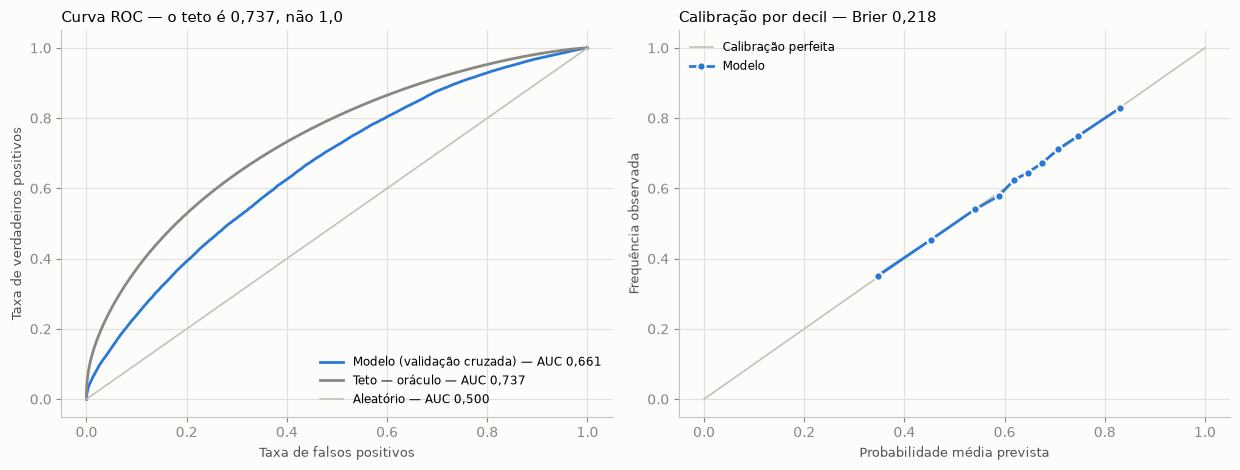

In [12]:
fig, eixos = plt.subplots(1, 2, figsize=(12.5, 4.8))

# --- Painel A: curva ROC, com o teto no mesmo eixo ---
for cor, (rotulo, probabilidade) in zip(
    [SERIE[0], MUDO],
    [("Modelo (validação cruzada)", prob_cv), ("Teto — oráculo", oraculo)],
):
    fpr, tpr, _ = roc_curve(y, probabilidade, sample_weight=peso)
    auc = avaliar(y, probabilidade, peso)["auc"]
    eixos[0].plot(fpr, tpr, color=cor, linewidth=2, label=f"{rotulo} — AUC {num(auc, 3)}")
eixos[0].plot([0, 1], [0, 1], color=EIXO, linewidth=1.2, label="Aleatório — AUC 0,500")
eixos[0].set_title("Curva ROC — o teto é 0,737, não 1,0", loc="left")
eixos[0].set_xlabel("Taxa de falsos positivos")
eixos[0].set_ylabel("Taxa de verdadeiros positivos")
eixos[0].legend(loc="lower right", fontsize=8.5)
limpar(eixos[0])
eixos[0].grid(axis="x", color=GRADE, linewidth=0.8)

# --- Painel B: calibração ---
calibracao = curva_calibracao(y, prob_cv, peso, n_faixas=10)
eixos[1].plot([0, 1], [0, 1], color=EIXO, linewidth=1.2, label="Calibração perfeita")
eixos[1].plot(calibracao["previsto"], calibracao["observado"], color=SERIE[0], linewidth=2,
              marker="o", markersize=6, markerfacecolor=SERIE[0],
              markeredgecolor="#fcfcfb", markeredgewidth=1.5, label="Modelo")
eixos[1].set_title(f"Calibração por decil — Brier {num(desempenho['brier'], 3)}", loc="left")
eixos[1].set_xlabel("Probabilidade média prevista")
eixos[1].set_ylabel("Frequência observada")
eixos[1].legend(loc="upper left", fontsize=8.5)
limpar(eixos[1])
eixos[1].grid(axis="x", color=GRADE, linewidth=0.8)

fig.tight_layout()
salvar(fig, "03_roc_calibracao")
plt.show()

A curva de calibração é o resultado que dá utilidade prática ao modelo: os pontos ficam sobre a
diagonal, ou seja, quando ele prevê 40% de alfabetização, a frequência observada é próxima de
40%. **A saída pode ser lida como "taxa esperada", e não apenas como uma ordenação** — que é
exatamente o que um gestor precisa para dimensionar uma intervenção.

In [13]:
matriz_confusao(y, prob_cv, peso, limiar=0.5)

,previsto: não alfabetizado,previsto: alfabetizado
real: não alfabetizado,1273.7,2917.0
real: alfabetizado,841.3,5864.0


**A matriz de confusão a 0,5 mostra por que a acurácia seria uma métrica enganosa aqui.** Como a
taxa média nacional é 61,5%, quase todo município recebe probabilidade acima de 0,5 — o modelo
classifica quase todos os alunos como "alfabetizado" e ainda assim acerta a maioria. Uma acurácia
alta não diria nada.

O que importa não é a classificação binária em 0,5: é a **ordenação** (AUC/KS, para priorizar
municípios) e a **calibração** (Brier, para dimensionar o esforço). O limiar operacional de
priorização — quais municípios entram na lista de intervenção — é uma decisão de política, não
de estatística, e é tratada no [notebook 04](04_aplicacao_estrategica.ipynb).

---

## 7. O modelo final

Ajustado sobre toda a base, com `C = 1,0`. É este objeto que responde às perguntas de
interpretabilidade e que alimenta a aplicação estratégica.

In [14]:
modelo_final = construir_pipeline(C=1.0)
modelo_final.fit(X, y, modelo__sample_weight=peso)

nomes = nomes_das_features(modelo_final)
coeficientes = pd.Series(modelo_final.named_steps["modelo"].coef_[0], index=nomes)

print(f"{len(nomes)} features após o pré-processamento "
      f"({len([n for n in nomes if n.startswith('sigla_uf')])} dummies de UF)")
print(f"Intercepto: {modelo_final.named_steps['modelo'].intercept_[0]:.4f}")

53 features após o pré-processamento (24 dummies de UF)
Intercepto: 0.4113


---

## 8. Interpretabilidade

O enunciado pede explicitamente Feature Importance e SHAP. Usamos **três** lentes, porque cada
uma responde a uma pergunta diferente — e a convergência entre elas é o que dá confiança:

| Lente | Pergunta que responde |
|---|---|
| Coeficientes em *odds ratio* | qual o **efeito** de mover uma variável, mantendo o resto constante? |
| Permutation importance | quanto o modelo **perde de desempenho** sem essa variável? |
| SHAP | quanto cada variável **contribuiu** para cada predição individual? |

Como todas as numéricas foram padronizadas, os coeficientes são diretamente comparáveis entre si:
cada um mede o efeito de **um desvio-padrão** da variável.

In [15]:
tabela_coef = pd.DataFrame({
    "coeficiente": coeficientes,
    "odds_ratio": np.exp(coeficientes),
}).assign(magnitude=coeficientes.abs())

sem_uf = tabela_coef[~tabela_coef.index.str.startswith("sigla_uf")]
sem_uf.sort_values("magnitude", ascending=False).head(12).round(4)

,coeficiente,odds_ratio,magnitude
ideb_2021,0.2851,1.3299,0.2851
media_inse,0.1183,1.1256,0.1183
capital_desc_interior,0.0855,1.0892,0.0855
missingindicator_ideb_2021,-0.0818,0.9215,0.0818
missingindicator_taxa_aprovacao_2021,0.0804,1.0837,0.0804
atu_anos_iniciais,-0.0664,0.9357,0.0664
afd_ai_grupo_1,0.0603,1.0622,0.0603
atu_2_ano,-0.0551,0.9464,0.0551
afd_ai_grupo_3,0.0415,1.0423,0.0415
ied_ai_nivel_4,-0.0353,0.9653,0.0353


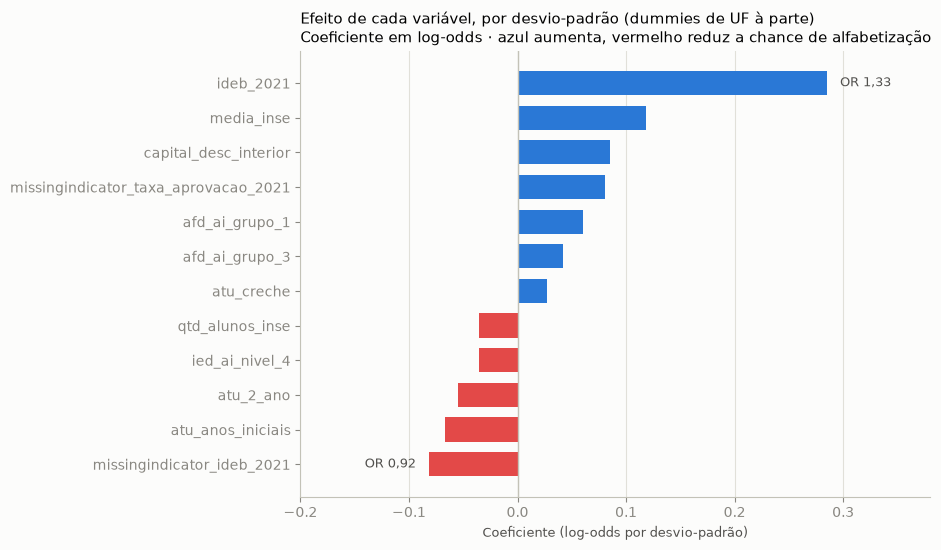

In [16]:
principais = sem_uf.sort_values("magnitude", ascending=False).head(12).sort_values("coeficiente")

fig, eixo = plt.subplots(figsize=(9.5, 5.6))
eixo.barh(principais.index, principais["coeficiente"],
          color=[NEGATIVO if v < 0 else POSITIVO for v in principais["coeficiente"]], height=0.7)
eixo.axvline(0, color=EIXO, linewidth=1)

for nome in (principais.index[0], principais.index[-1]):
    valor = principais.loc[nome, "coeficiente"]
    razao = principais.loc[nome, "odds_ratio"]
    deslocamento = 0.012 if valor > 0 else -0.012
    eixo.text(valor + deslocamento, nome, f"OR {num(razao)}", va="center",
              ha="left" if valor > 0 else "right", fontsize=9, color=TINTA_2)

eixo.set_title("Efeito de cada variável, por desvio-padrão (dummies de UF à parte)\n"
               "Coeficiente em log-odds · azul aumenta, vermelho reduz a chance de alfabetização",
               loc="left")
eixo.set_xlabel("Coeficiente (log-odds por desvio-padrão)")
eixo.set_xlim(-0.20, 0.38)
limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "03_coeficientes")
plt.show()

**Leitura dos principais efeitos** (lembrando: por desvio-padrão, mantendo o resto constante):

- **`ideb_2021` — OR 1,33.** O maior efeito individual fora da geografia. Um desvio-padrão a mais
  no IDEB de 2021 multiplica por 1,33 a chance de um aluno estar alfabetizado dois anos depois.
- **`media_inse` — OR 1,13.** O nível socioeconômico tem efeito próprio, mas **menos da metade**
  do desempenho pregresso.
- **`missingindicator_ideb_2021` — OR 0,92.** O município **não ter IDEB divulgado** reduz a
  chance prevista. A decisão de imputar com `add_indicator=True` se pagou: a ausência era sinal.
- **`atu_anos_iniciais` — OR 0,94.** Turmas maiores nos anos iniciais reduzem a chance.
- **`afd_ai_grupo_1` — OR 1,06.** Deslocar um desvio-padrão de docentes para "licenciatura na
  área que leciona" (contra a referência, "sem curso superior") aumenta a chance.
- **`capital_desc_interior` — OR 1,09.** Municípios do interior vão **melhor** que as capitais,
  controlado o resto — resultado contraintuitivo que a §9 retoma.

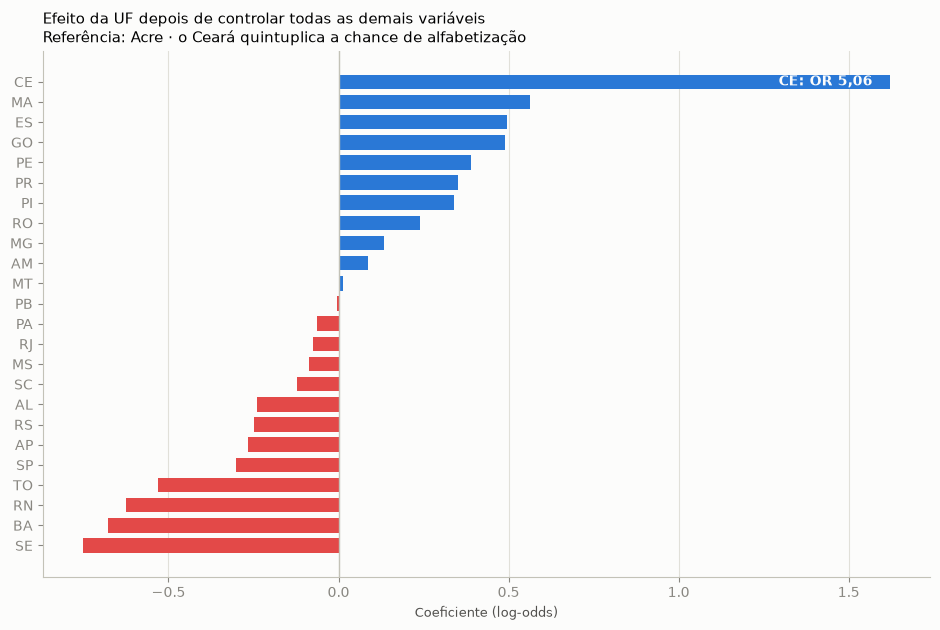

In [17]:
com_uf = tabela_coef[tabela_coef.index.str.startswith("sigla_uf")].sort_values("coeficiente")
com_uf.index = com_uf.index.str.replace("sigla_uf_", "", regex=False)

fig, eixo = plt.subplots(figsize=(9.5, 6.4))
eixo.barh(com_uf.index, com_uf["coeficiente"],
          color=[NEGATIVO if v < 0 else POSITIVO for v in com_uf["coeficiente"]], height=0.72)
eixo.axvline(0, color=EIXO, linewidth=1)

destaque = com_uf["coeficiente"].idxmax()
eixo.text(com_uf.loc[destaque, "coeficiente"] - 0.05, destaque,
          f"{destaque}: OR {num(com_uf.loc[destaque, 'odds_ratio'])}", va="center", ha="right",
          fontsize=10, fontweight="bold", color="#fcfcfb")

eixo.set_title("Efeito da UF depois de controlar todas as demais variáveis\n"
               "Referência: Acre · o Ceará quintuplica a chance de alfabetização", loc="left")
eixo.set_xlabel("Coeficiente (log-odds)")
limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "03_coeficientes_uf")
plt.show()

**Este é o gráfico mais importante do projeto.**

Depois de controlar IDEB pregresso, nível socioeconômico, formação docente, tamanho de turma,
esforço docente, ruralidade e porte, **o Ceará ainda multiplica por 5,1 a chance de um aluno
estar alfabetizado**. É, de longe, o maior efeito do modelo — maior que qualquer variável
mensurável.

O que essa dummy captura é justamente o que a base **não** mede: política pública estadual. O
Ceará opera desde 2007 o PAIC, o programa de alfabetização mais antigo e consolidado do país, que
serviu de referência para o desenho do Compromisso Nacional Criança Alfabetizada. O modelo não
sabe disso — ele apenas registra que sobra um efeito enorme, específico daquele estado, que
nenhuma outra variável explica.

Na outra ponta, Sergipe, Bahia e Rio Grande do Norte têm as chances aproximadamente **reduzidas
à metade** em relação à referência, mesmo controlando o contexto socioeconômico.

*Nota de cobertura:* aparecem 24 dummies e a referência (Acre) — **25 UFs, não 27**. O Distrito
Federal não tem rede municipal (não há municípios no DF), e **Roraima está inteiramente ausente
do arquivo do INEP**, em qualquer rede e nos dois ciclos. É uma lacuna da fonte, não da pipeline;
entra nas limitações.

In [18]:
importancia = permutation_importance(
    modelo_final, X, y, scoring="roc_auc", n_repeats=5,
    random_state=SEMENTE, sample_weight=peso, n_jobs=1,
)
pd.DataFrame({
    "queda_no_auc": importancia.importances_mean,
    "desvio": importancia.importances_std,
}, index=X.columns).sort_values("queda_no_auc", ascending=False).head(10).round(5)

,queda_no_auc,desvio
sigla_uf,0.08014,0.00242
ideb_2021,0.04165,0.00199
media_inse,0.00742,0.00055
taxa_aprovacao_2021,0.00294,0.00043
atu_anos_iniciais,0.00213,0.00051
afd_ai_grupo_1,0.00154,0.00034
atu_2_ano,0.00149,0.00040
afd_ai_grupo_3,0.00118,0.00058
ied_ai_nivel_4,0.00071,0.00020
qtd_alunos_inse,0.00060,0.00010


A *permutation importance* opera sobre as colunas **originais**, então `sigla_uf` aparece como um
bloco único — e é exatamente por isso que ela é informativa aqui: embaralhar a UF derruba o AUC
em **0,080**, quase o dobro do IDEB (0,042) e mais de dez vezes o nível socioeconômico (0,007).

Confirma o que os coeficientes já sugeriam: **a geografia é o preditor mais forte do modelo**, e
não como um detalhe de controle — como o fator dominante.

Background dataset has 21792 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=21792 when initializing the masker.


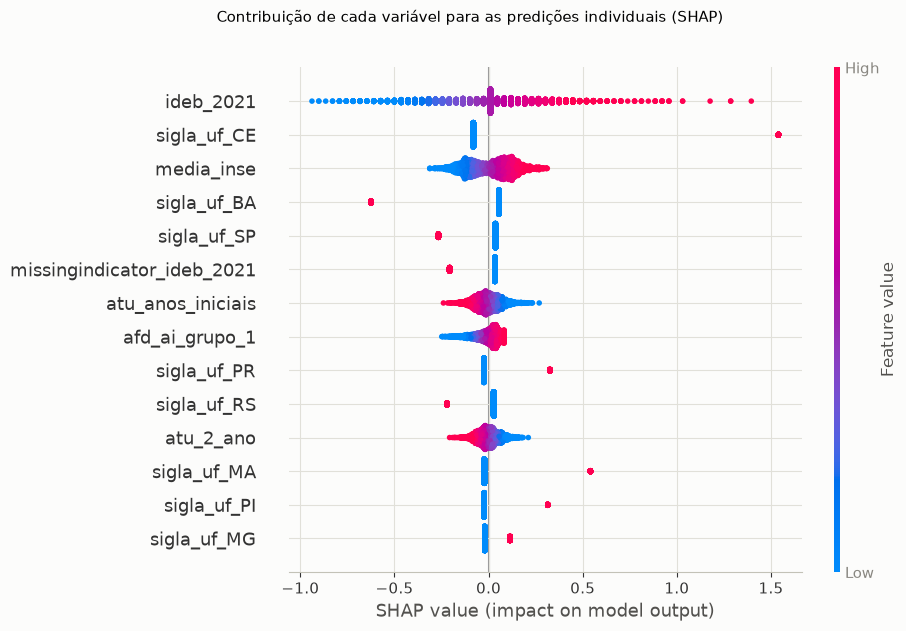

In [19]:
import shap

matriz = modelo_final.named_steps["preprocessamento"].transform(X)
amostra = np.random.default_rng(SEMENTE).choice(len(matriz), size=4000, replace=False)

explicador = shap.LinearExplainer(modelo_final.named_steps["modelo"], matriz)
valores_shap = explicador.shap_values(matriz[amostra])

shap.summary_plot(valores_shap, matriz[amostra], feature_names=nomes,
                  max_display=14, show=False, plot_size=(9.5, 6.2))
fig = plt.gcf()
fig.suptitle("Contribuição de cada variável para as predições individuais (SHAP)",
             fontsize=11, y=1.01)
fig.tight_layout()
salvar(fig, "03_shap_summary")
plt.show()

In [20]:
pd.Series(np.abs(valores_shap).mean(axis=0), index=nomes) \
  .sort_values(ascending=False).head(12).round(4).rename("SHAP médio absoluto").to_frame()

,SHAP médio absoluto
ideb_2021,0.2166
sigla_uf_CE,0.1313
media_inse,0.1049
sigla_uf_BA,0.1000
sigla_uf_SP,0.0640
missingindicator_ideb_2021,0.0558
atu_anos_iniciais,0.0523
afd_ai_grupo_1,0.0457
sigla_uf_PR,0.0449
sigla_uf_RS,0.0439


As três lentes convergem, o que é o melhor sinal possível de que a leitura está correta:

| | Coeficientes | Permutation | SHAP |
|---|---|---|---|
| 1º | `sigla_uf_CE` (1,62) | `sigla_uf` (0,080) | `ideb_2021` (0,217) |
| 2º | `ideb_2021` (0,285) | `ideb_2021` (0,042) | `sigla_uf_CE` (0,131) |
| 3º | `media_inse` (0,118) | `media_inse` (0,007) | `media_inse` (0,105) |

As três apontam o mesmo trio; a ordem interna difere porque medem coisas distintas. O
coeficiente do Ceará é o maior de todos, mas o SHAP mede a contribuição **média por predição** e
aquela dummy só se ativa em **184 dos 5.500 municípios**. O IDEB, presente em todos, acaba
contribuindo mais no agregado. A *permutation* trata `sigla_uf` como bloco único, e por isso a
geografia aparece nela em primeiro lugar.

---

## 9. Testando as hipóteses da análise exploratória

A EDA registrou cinco hipóteses **antes** de o modelo existir. Testá-las agora é o que impede a
análise de virar racionalização do resultado.

In [21]:
# H2 exige um teste específico: o coeficiente de media_inse com e sem as dummies de UF.
def coeficiente_inse(com_dummies_uf: bool) -> float:
    originais = F.CATEGORICAS
    F.CATEGORICAS = originais if com_dummies_uf else ["capital_desc"]
    try:
        m = construir_pipeline(C=1.0)
        m.fit(X, y, modelo__sample_weight=peso)
        return pd.Series(m.named_steps["modelo"].coef_[0],
                         index=nomes_das_features(m))["media_inse"]
    finally:
        F.CATEGORICAS = originais

pd.Series({
    "coeficiente de media_inse SEM as dummies de UF": round(coeficiente_inse(False), 4),
    "coeficiente de media_inse COM as dummies de UF": round(coeficiente_inse(True), 4),
}).to_frame("log-odds por desvio-padrão")

,log-odds por desvio-padrão
coeficiente de media_inse SEM as dummies de UF,0.0730
coeficiente de media_inse COM as dummies de UF,0.1183


| # | Hipótese | Veredito | Evidência |
|---|---|---|---|
| **H1** | O desempenho pregresso é o melhor preditor disponível | **Confirmada** | `ideb_2021` é o maior coeficiente fora da geografia (OR 1,33) e a 2ª maior queda de AUC na permutação (0,042) |
| **H2** | O efeito socioeconômico é **muito menor** do que a correlação bruta sugere | **Confirmada em magnitude, refutada no mecanismo** | ver abaixo |
| **H3** | A qualificação docente tem efeito próprio | **Confirmada, mas fraca** | `afd_ai_grupo_1` OR 1,06 na direção esperada, controlado o contexto — efeito real, porém pequeno |
| **H4** | Há efeito de gestão estadual não capturado pelas variáveis observáveis | **Fortemente confirmada** | `sigla_uf_CE` OR **5,06** após controlar tudo o mais; UF é a variável mais importante na permutação |
| **H5** | Municípios rurais e pequenos enfrentam desvantagem estrutural | **Parcialmente confirmada** | `proporcao_rural` OR 0,97 e `missingindicator_ideb_2021` OR 0,92, ambos na direção esperada, mas fracos. `capital_desc_interior` OR 1,09 vai na direção **oposta** |

### H2 merece ser tratada com cuidado — a previsão que registrei estava errada

Na EDA eu registrei, antes de treinar, a expectativa de que o coeficiente de `media_inse`
ficaria **bem menor** do que a correlação bruta de 0,30 sugeria, e que controlar por UF o
**encolheria**.

A primeira parte se confirmou: o efeito é modesto (OR 1,13, contra 1,33 do IDEB). **A segunda
está errada.** Controlar por UF *aumentou* o coeficiente, de 0,073 para 0,118 — ele
aproximadamente dobrou.

A explicação é que eu comparei quantidades diferentes. A EDA mediu uma correlação **bivariada**,
na qual o INSE estava confundido com a região. O coeficiente do modelo é **parcial**: mede o
efeito do INSE mantendo constantes a UF e outras trinta variáveis. Ao remover a variação
*entre* regiões — que incluía o gradiente negativo do Nordeste puxando a estimativa conjunta
para baixo — sobra a variação *dentro* de cada UF, e aí o sinal aparece mais limpo e maior. É um
efeito de supressão, não uma contradição.

A conclusão prática permanece a mesma, e é a que importa para a narrativa executiva: **o nível
socioeconômico não determina o resultado**. Ele tem efeito próprio e mensurável, porém menor que
o do desempenho pregresso e muito menor que o da política estadual.

### H5 e o resultado contraintuitivo do interior

`capital_desc_interior` com OR 1,09 diz que, controlado todo o resto, municípios do interior vão
**melhor** que as capitais. Não é o que a hipótese previa. Duas leituras possíveis, nenhuma
verificável com esta base: capitais concentram redes municipais grandes, com escolas em
territórios de alta vulnerabilidade que o INSE médio municipal dilui; ou o porte
(`qtd_alunos_inse`, também negativo, OR 0,97) está capturando uma dificuldade de gestão que
cresce com a escala. Fica registrado como achado aberto.

---

## 10. Por que Regressão Logística — e por que não os outros

A escolha foi feita antes de ver os resultados, e vale explicitá-la junto com o descarte.

**Por que a Regressão Logística é a escolha certa aqui:**

1. **O alvo é literalmente binomial.** Não é uma adaptação: dado binário agrupado com
   `sample_weight` é exatamente o que uma logística binomial estima. Qualquer outro algoritmo
   estaria sendo forçado a um formato que não é o seu.
2. **Coeficientes em *odds ratio* falam a língua do gestor.** "Estar no Ceará multiplica por 5 a
   chance" é uma frase que sustenta uma decisão de política pública. Uma importância relativa de
   árvore não é.
3. **A saída é calibrada** e pode ser lida como taxa esperada — verificado na §6.
4. **O valor deste projeto está na explicação, não no ganho marginal de métrica.** O teto é 0,737;
   disputar centésimos abaixo dele com um modelo opaco trocaria o que interessa pelo que não
   interessa.

**Por que não os outros** (algoritmos vistos nas aulas):

| Algoritmo | Por que foi descartado |
|---|---|
| Árvore de Decisão | ganharia em capturar não-linearidades, mas o efeito dominante (UF) é categórico e já é linear em log-odds; perderia a leitura em *odds ratio* e ficaria instável com 27 dummies |
| SVM | não produz probabilidade calibrada nativamente, e calibração é metade do valor aqui; sem interpretabilidade direta |
| Naive Bayes | assume independência entre variáveis — premissa insustentável numa base com blocos composicionais que somam 100% |
| Ensembles (RF, XGBoost) | teriam desempenho semelhante contra um teto de 0,737 e custariam a interpretabilidade que é o produto do projeto |

O escopo é deliberadamente enxuto: **um modelo bem justificado e bem interpretado**, não uma
varredura de algoritmos. A comparação que importa não é contra outro algoritmo — é contra o
**piso e o teto** da §4, que é o que diz se o modelo aprendeu alguma coisa.

---

## 11. Limitações do modelo

Declaradas aqui e retomadas no README:

1. **Falácia ecológica.** O modelo estima a probabilidade de um aluno *típico* de um município,
   não de uma criança específica. Nenhuma característica individual entra.
2. **Peso por município, não por aluno.** Cada município conta 1, independentemente do porte. A
   base não traz o número de alunos avaliados.
3. **Ausência de variáveis de política educacional.** É a lacuna mais séria: o maior efeito do
   modelo (a dummy do Ceará) é justamente um efeito que o modelo **não consegue explicar**, só
   registrar. Formação continuada, material estruturado e regime de colaboração não estão na base.
4. **INSE de 2023 replicado para 2024**, tratado como atributo estrutural do município.
5. **AFD, ATU e IED usam o agregado `Total`**, que inclui a rede privada, enquanto o alvo é da
   rede municipal. São medidas de contexto do município, não da rede.
6. **Apenas dois ciclos avaliativos.** Não há como separar efeito de tendência de efeito de
   choque, nem estimar dinâmica.
7. **Cobertura territorial incompleta.** A base cobre **25 das 27 UFs** e 5.500 dos 5.570
   municípios brasileiros. O Distrito Federal não tem rede municipal; **Roraima está ausente do
   arquivo do INEP** em qualquer rede e nos dois ciclos. Conclusões não se estendem a esses
   territórios.
8. **Correlação não é causalidade.** Nada aqui é um experimento; os coeficientes são associações
   condicionais, e recomendações derivadas deles precisam de validação causal.

---

## Conclusão

| Referência | AUC | Brier |
|---|---|---|
| Piso — prever a média nacional | 0,500 | 0,237 |
| **Modelo — Regressão Logística (validação cruzada)** | **0,661** | **0,218** |
| Teto — oráculo com a taxa observada | 0,737 | 0,198 |

O modelo percorre **68% do intervalo entre o piso e o teto** usando apenas informação disponível
*antes* de a avaliação acontecer. No teste de generalização temporal — treinado em 2023, avaliado
em 2024 — atinge 0,672 excluindo o Rio Grande do Sul, acima da própria validação cruzada. Está
calibrado, não apresenta overfitting (diferença treino-validação de 0,0015) e produz uma
explicação consistente entre coeficientes, permutation importance e SHAP.

O achado central não é a métrica: é que, **controlado todo o resto que se consegue medir, a
unidade federativa é o fator mais importante** — e o Ceará quintuplica a chance de alfabetização.
O que separa os municípios brasileiros não é principalmente a renda das famílias; é a política
pública que cada estado escolheu executar.

**Próximo passo:** [`04_aplicacao_estrategica.ipynb`](04_aplicacao_estrategica.ipynb) — traduzir
isso em respostas às perguntas de negócio: quais municípios estão em maior risco, quais regiões
têm padrões semelhantes, e quais podem não atingir as metas futuras.